![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

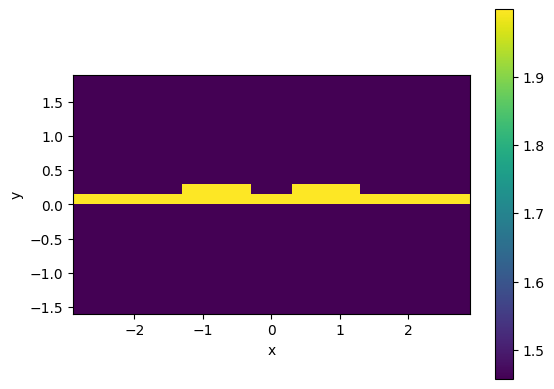

In [ ]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1, 1), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=8, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-01 21:01:37.002 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_35db2e2c835b791a.npz.


[1.61593334+0.00010473j 1.59618939+0.00010301j 1.53961336+0.00017954j
 1.52798995+0.00015282j 1.52073881+0.00015411j 1.516726  +0.00018101j
 1.47875274+0.00014637j 1.45156605+0.00020708j]


In [6]:
dcoupler_cs.fraction_te

array([0.99608423, 0.99590382, 0.00926979, 0.93662072, 0.99388697,
       0.03654714, 0.98122897, 0.00732035])

In [7]:
dcoupler_cs.fraction_tm

array([0.00391577, 0.00409618, 0.99073021, 0.06337928, 0.00611303,
       0.96345286, 0.01877103, 0.99267965])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

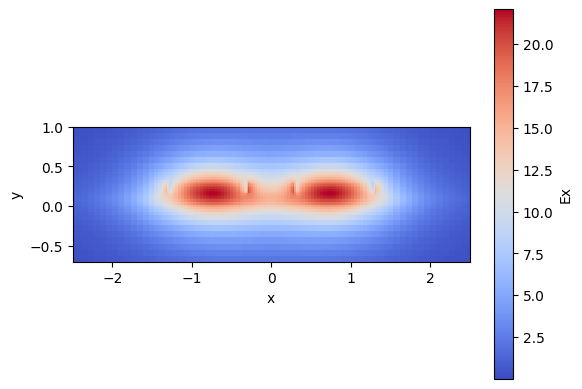

In [15]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

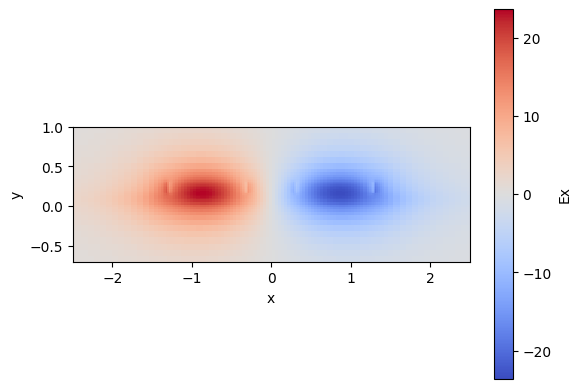

In [16]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

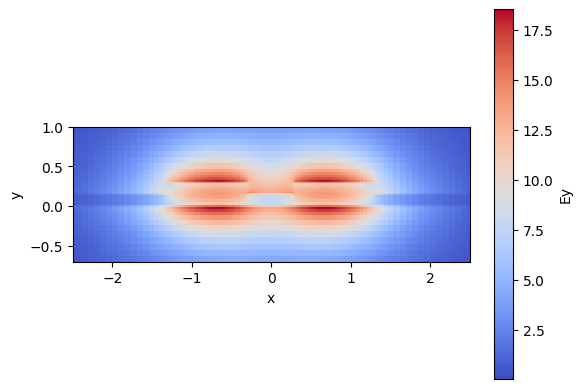

In [17]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

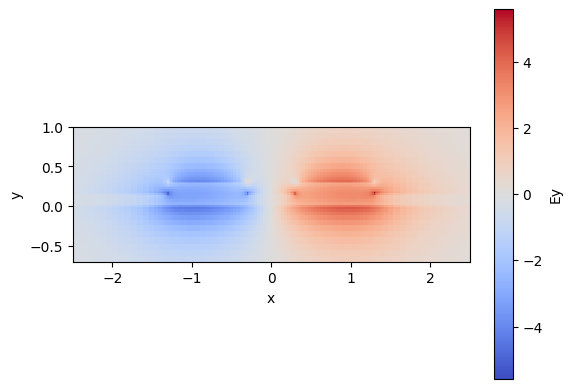

In [18]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [19]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

39.25252888639486
66.67576829904992


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [20]:
dcoupler_cs.coupling_length()

array([ 39.25252889,  66.6757683 , 193.13150842,  28.50659346])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

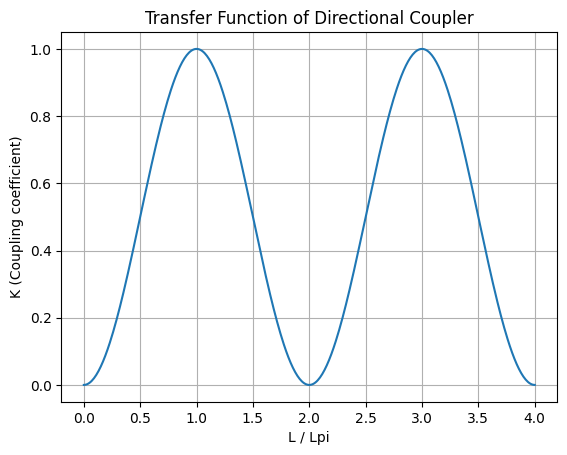

In [5]:
L_norm = np.linspace(0, 4, 400)  # L / Lpi

# Transfer function
K = np.sin((np.pi / 2) * L_norm)**2

# Plot
plt.figure()
plt.plot(L_norm, K)

plt.xlabel("L / Lpi")
plt.ylabel("K (Coupling coefficient)")
plt.title("Transfer Function of Directional Coupler")
plt.grid()

plt.show()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [12]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 1 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.8841520762867  µm


/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']


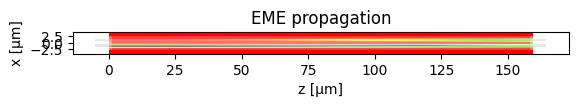

In [13]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [23]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-01 21:16:10.221 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [24]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

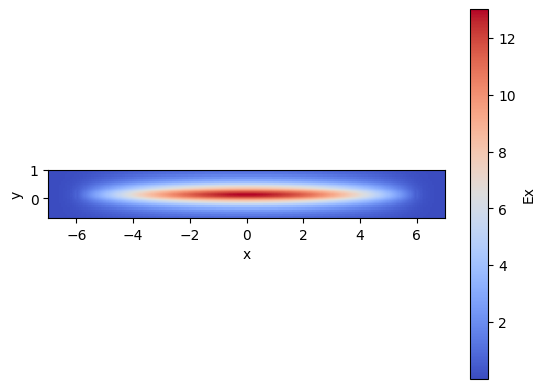

In [25]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

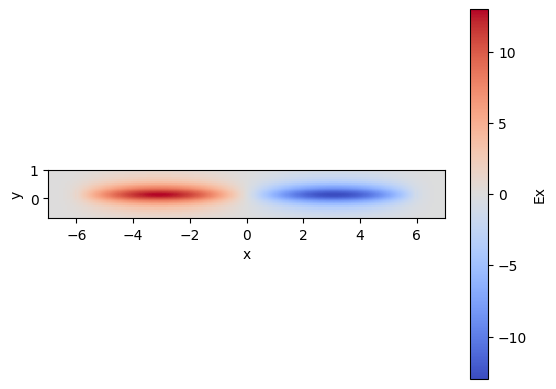

In [26]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

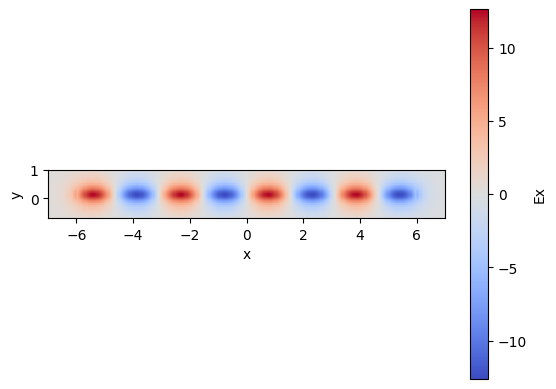

In [27]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [28]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794414357


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [35]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607258189  µm


/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


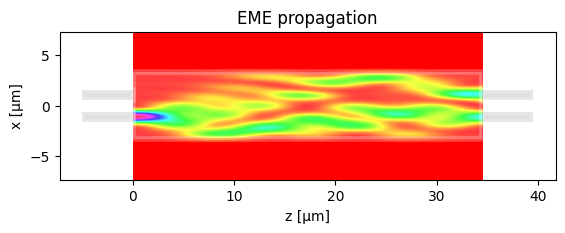

In [36]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/676 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.7000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.8996
Excess loss [dB] =  0.4594
------------------------
Power over OUTs:  ['0.4504', '0.4492']
Ratio over OUTs ['0.5007', '0.4993']


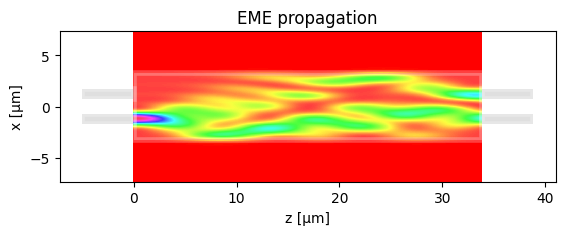

In [37]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.7  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [38]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.7 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607257916  µm


/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.7000
------------------------
Total power IN coupled 0.9924
Total OUT power: 0.9833
Excess loss [dB] =  0.0732
------------------------
Power over OUTs:  ['0.5017', '0.4816']
Ratio over OUTs ['0.5102', '0.4898']


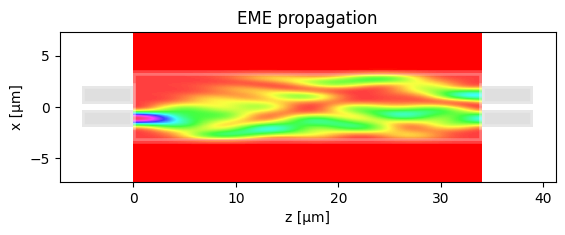

In [39]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [22]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 12 # Student. Body width


m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 1.2
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544097213  µm


/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/792 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.5000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 0.9970
Total OUT power: 0.9820
Excess loss [dB] =  0.0788
------------------------
Power over OUTs:  ['0.2385', '0.2525', '0.2525', '0.2385']
Ratio over OUTs ['0.2429', '0.2571', '0.2572', '0.2428']


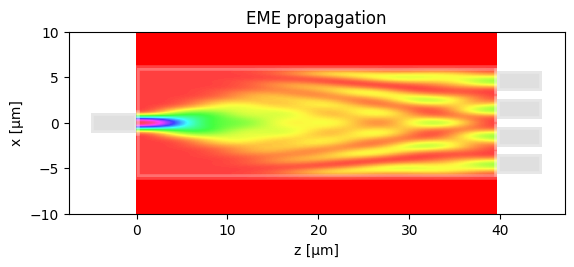

In [23]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.02
dy2 = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0.0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8, 3/8]) + np.array([-dy2, -dy, dy ,dy2]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi # STUDENT
m.dL_MMI = -1.5 # STUDENT

# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)


2026-05-01 21:14:18.144 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-05-01 21:14:18.195 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
2026-05-01 21:14:18.204 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.
2026-05-01 21:14:18.217 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
2026-05-01 21:14:18.227 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
2026-05-01 21:14:18.234 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad149.npz.
2026-05-01 21:14:18.254 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_69d8430ee5b848c9.npz.
2026-05-01 21:14:18.267 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

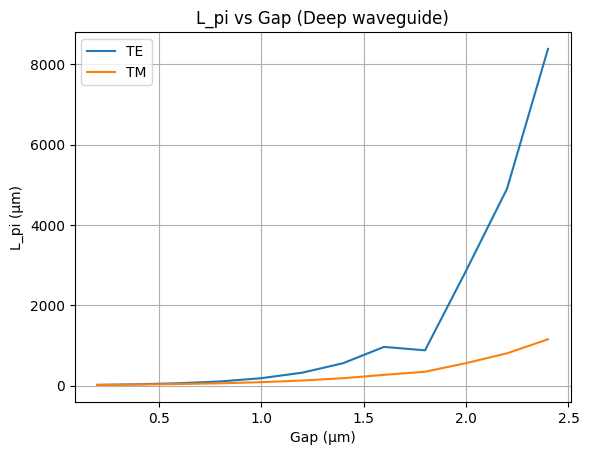

In [13]:
gaps = np.arange(0.2, 2.6, 0.2)  # en µm
Lpi_TE_list = []
Lpi_TM_list = []

lambda_c = 1.55  # µm

for gap in gaps:
    dc = gt.modes.WaveguideCoupler(
        wavelength=lambda_c,
        core_width=(1.0, 1.0),
        gap=gap,
        slab_thickness=0,  # DEEP
        core_thickness=0.3,
        core_material='sin',
        clad_material='sio2',
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    neff = dc.n_eff

    # TE (modos 0 y 1)
    Lpi_TE = 0.5 * lambda_c / (neff[0].real - neff[1].real)

    # TM (modos 2 y 3)
    Lpi_TM = 0.5 * lambda_c / (neff[2].real - neff[3].real)

    Lpi_TE_list.append(Lpi_TE)
    Lpi_TM_list.append(Lpi_TM)

plt.figure()
plt.plot(gaps, Lpi_TE_list, label='TE')
plt.plot(gaps, Lpi_TM_list, label='TM')
plt.xlabel('Gap (µm)')
plt.ylabel('L_pi (µm)')
plt.title('L_pi vs Gap (Deep waveguide)')
plt.legend()
plt.grid()
plt.show()

2026-05-01 21:14:32.010 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c5c249f6ae0bb2d2.npz.
2026-05-01 21:14:32.030 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_40eebff1fd750837.npz.
2026-05-01 21:14:32.037 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_4c9023fc33309393.npz.
2026-05-01 21:14:32.042 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0eacaacf5aa49091.npz.
2026-05-01 21:14:32.063 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5c31aa701e5b954b.npz.
2026-05-01 21:14:32.079 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0c99a6d68e789e6b.npz.
2026-05-01 21:14:32.085 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ffa957e78f93147d.npz.
2026-05-01 21:14:32.092 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

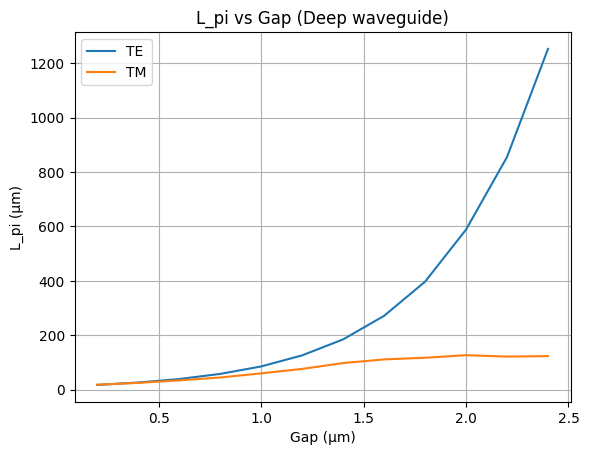

In [14]:
gaps = np.arange(0.2, 2.6, 0.2)  # en µm
Lpi_TE_list = []
Lpi_TM_list = []

lambda_c = 1.55  # µm

for gap in gaps:
    dc = gt.modes.WaveguideCoupler(
        wavelength=lambda_c,
        core_width=(1.0, 1.0),
        gap=gap,
        slab_thickness=150*nm,  # SHALLOW
        core_thickness=300*nm,
        core_material='sin',
        clad_material='sio2',
        num_modes=6,
        cache_path='.cache/',
    )

    neff = dc.n_eff

    # TE (modos 0 y 1)
    Lpi_TE = 0.5 * lambda_c / (neff[0].real - neff[1].real)

    # TM (modos 2 y 5)
    Lpi_TM = 0.5 * lambda_c / (neff[2].real - neff[5].real)

    Lpi_TE_list.append(Lpi_TE)
    Lpi_TM_list.append(Lpi_TM)

plt.figure()
plt.plot(gaps, Lpi_TE_list, label='TE')
plt.plot(gaps, Lpi_TM_list, label='TM')
plt.xlabel('Gap (µm)')
plt.ylabel('L_pi (µm)')
plt.title('L_pi vs Gap (Deep waveguide)')
plt.legend()
plt.grid()
plt.show()

### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = np.arange(0.2, 2.4, 0.2)# STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here


2026-05-01 12:59:39.331 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7fb4453216b17d7.npz.


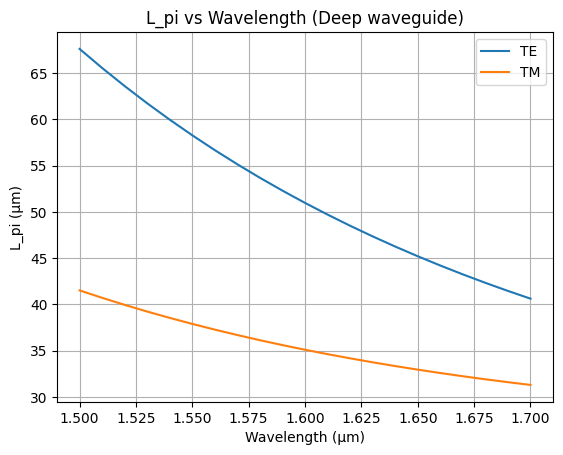

In [25]:
wavelength = np.linspace(1.5, 1.7, 21)  # µm

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength,
    core_width=(1.0, 1.0),
    gap=0.6,
    slab_thickness=0.0,  # DEEP
    core_material='sin',
    clad_material='sio2',
    core_thickness=0.3,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

deep_neff = deep_dcoupler_cs.n_eff

# modo 0 y 1 para TE
Lpi_TE = 0.5 * wavelength / (deep_neff[:, 0].real - deep_neff[:, 1].real)

# modo 2 y 3 para TM
Lpi_TM = 0.5 * wavelength / (deep_neff[:, 2].real - deep_neff[:, 3].real)

plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')
plt.xlabel('Wavelength (µm)')
plt.ylabel('L_pi (µm)')
plt.title('L_pi vs Wavelength (Deep waveguide)')
plt.legend()
plt.grid()
plt.show()

2026-05-01 13:19:04.026 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_5a87835691375598.npz.


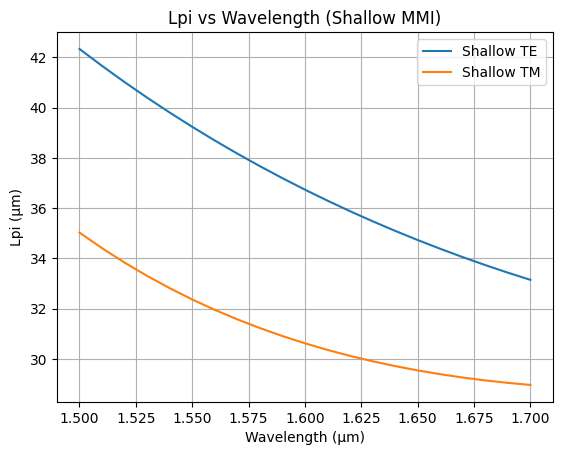

In [41]:

wavelength = np.linspace(1.5, 1.7, 21)  # µm

shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength,
    core_width=(1.0, 1.0),
    gap=0.6,
    slab_thickness=150 * nm,  # SHALLOW
    core_material='sin',
    clad_material='sio2',
    core_thickness=0.3,
    num_modes=6,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

shallow_neff = shallow_dcoupler_cs.n_eff

# TE
Lpi_shallow_TE = 0.5 * wavelength / (shallow_neff[:, 0].real - shallow_neff[:, 1].real)

# TM
Lpi_shallow_TM = 0.5 * wavelength / (shallow_neff[:, 2].real - shallow_neff[:, 5].real)

# Plot
plt.figure()

plt.plot(wavelength, Lpi_shallow_TE, label="Shallow TE")
plt.plot(wavelength, Lpi_shallow_TM, label="Shallow TM")

plt.xlabel("Wavelength (µm)")
plt.ylabel("Lpi (µm)")
plt.title("Lpi vs Wavelength (Shallow MMI)")
plt.legend()
plt.grid()

plt.show()

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

2026-05-01 13:25:18.077 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f39d4c3cde953a59.npz.


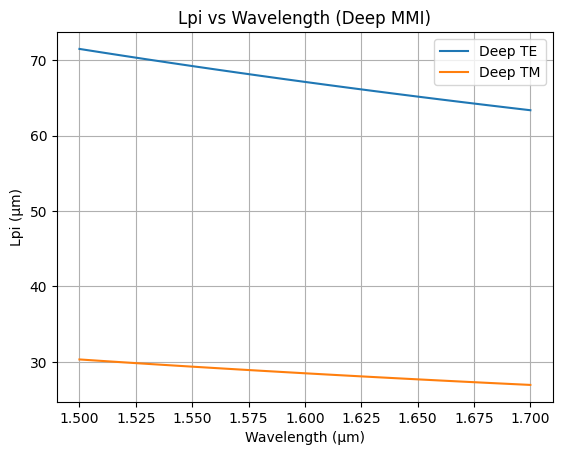

In [45]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.7, 21)  # µm

mmi_body_waveguide = gt.modes.Waveguide(
    core_width=mmi_body_w,
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    core_material='sin',
    clad_material='sio2',
    wavelength=lambda_c,
    num_modes=4,
    cache_path='.cache/'
)

deep_neff = mmi_body_waveguide.n_eff

# modo 0 y 1 para TE
Lpi_deep_TE = 0.5 * wavelength / (deep_neff[:, 0].real - deep_neff[:, 1].real)

# modo 2 y 3 para TM
Lpi_deep_TM = 0.5 * wavelength / (deep_neff[:, 2].real - deep_neff[:, 3].real)

# Plot
plt.figure()

plt.plot(lambda_c, Lpi_deep_TE, label="Deep TE")
plt.plot(lambda_c, Lpi_deep_TM, label="Deep TM")

plt.xlabel("Wavelength (µm)")
plt.ylabel("Lpi (µm)")
plt.title("Lpi vs Wavelength (Deep MMI)")
plt.legend()
plt.grid()

plt.show()

/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivat

2026-05-01 13:28:36.205 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ec87008bdb23f473.npz.


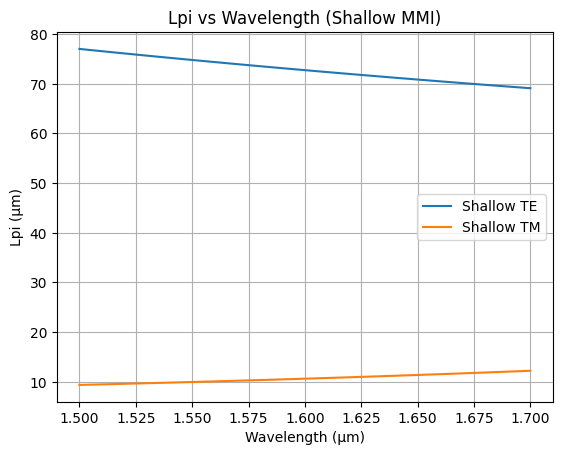

In [47]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.7, 21)  # µm

mmi_body_waveguide = gt.modes.Waveguide(
    core_width=mmi_body_w,
    core_thickness=300 * nm,
    slab_thickness=150 * nm, #SHALLOW
    core_material='sin',
    clad_material='sio2',
    wavelength=lambda_c,
    num_modes=6,
    cache_path='.cache/'
)

shallow_neff = mmi_body_waveguide.n_eff

# modo 0 y 1 para TE
Lpi_shallow_TE = 0.5 * wavelength / (shallow_neff[:, 0].real - shallow_neff[:, 1].real)

# modo 2 y 5 para TM
Lpi_shallow_TM = 0.5 * wavelength / (shallow_neff[:, 2].real - shallow_neff[:, 5].real)

# Plot
plt.figure()

plt.plot(lambda_c, Lpi_shallow_TE, label="Shallow TE")
plt.plot(lambda_c, Lpi_shallow_TM, label="Shallow TM")

plt.xlabel("Wavelength (µm)")
plt.ylabel("Lpi (µm)")
plt.title("Lpi vs Wavelength (Shallow MMI)")
plt.legend()
plt.grid()

plt.show()

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

2026-05-01 21:05:15.536 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7959a256e3b2f7e4.npz.
2026-05-01 21:05:15.566 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5998ddaac77406ad.npz.
2026-05-01 21:05:15.571 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e4bcc0353085fc03.npz.
2026-05-01 21:05:15.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5cd50dbaeff86f1c.npz.
2026-05-01 21:05:15.582 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_011ee398940bc887.npz.
2026-05-01 21:05:15.585 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_79908fa1cd2a92db.npz.
2026-05-01 21:05:15.636 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ffeb19aea10ccd4e.npz.
2026-05-01 21:05:15.643 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bbabf70b2b4f0737.npz.


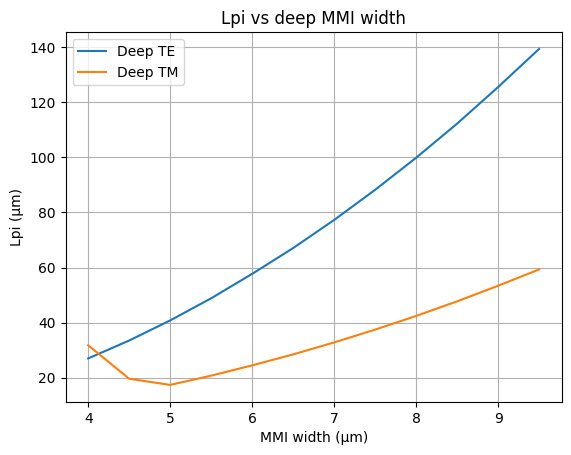

In [9]:
lambda_c = 1.55  # µm
mmi_widths = np.arange(4.0, 10.0, 0.5)

# Listas
Lpi_deep_TE = []
Lpi_deep_TM = []

for w in mmi_widths:

    # DEEP
    deep_wg = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=4,
        cache_path='.cache/'
    )

    deep_neff = deep_wg.n_eff

    # TE
    Lpi_deep_TE.append(0.5 * lambda_c / (deep_neff[0].real - deep_neff[1].real))

    # TM
    Lpi_deep_TM.append(0.5 * lambda_c / (deep_neff[2].real - deep_neff[3].real))

plt.figure()

plt.plot(mmi_widths, Lpi_deep_TE, label="Deep TE")
plt.plot(mmi_widths, Lpi_deep_TM, label="Deep TM")

plt.xlabel("MMI width (µm)")
plt.ylabel("Lpi (µm)")
plt.title("Lpi vs deep MMI width")
plt.legend()
plt.grid()

plt.show()


2026-05-01 21:09:40.925 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_107fe31b6e733267.npz.
2026-05-01 21:09:40.936 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_969e243222928121.npz.
2026-05-01 21:09:40.943 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_def9c444f2c226eb.npz.
2026-05-01 21:09:40.948 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fedb1ada82950da0.npz.
2026-05-01 21:09:40.956 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0f16c0f35ad93d6c.npz.
2026-05-01 21:09:40.958 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b1db64f12703166e.npz.


2026-05-01 21:09:40.965 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2ea4e4c4b12e18f5.npz.
2026-05-01 21:09:40.975 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ad865bcef5ae8265.npz.
2026-05-01 21:09:40.982 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c0eaad8795c6b9dc.npz.
2026-05-01 21:09:40.986 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f43057e7151dfed0.npz.
2026-05-01 21:09:40.993 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_07100567c12e4e59.npz.
2026-05-01 21:09:40.998 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_53ab60a0655013da.npz.


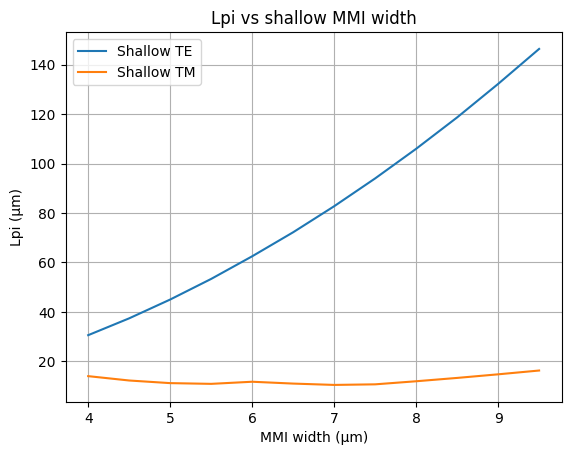

In [12]:
lambda_c = 1.55  # µm
mmi_widths = np.arange(4.0, 10.0, 0.5)

# Listas
Lpi_shallow_TE = []
Lpi_shallow_TM = []

for w in mmi_widths:

    # SHALLOW
    deep_wg = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=150* nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=6,
        cache_path='.cache/'
    )

    shallow_neff = deep_wg.n_eff

    # TE
    Lpi_shallow_TE.append(0.5 * lambda_c / (shallow_neff[0].real - shallow_neff[1].real))

    # TM
    Lpi_shallow_TM.append(0.5 * lambda_c / (shallow_neff[2].real - shallow_neff[5].real))

plt.figure()

plt.plot(mmi_widths, Lpi_shallow_TE, label="Shallow TE")
plt.plot(mmi_widths, Lpi_shallow_TM, label="Shallow TM")

plt.xlabel("MMI width (µm)")
plt.ylabel("Lpi (µm)")
plt.title("Lpi vs shallow MMI width")
plt.legend()
plt.grid()

plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points